# Return residualization: worked example

This notebook runs one explicit residualization composition on local marcap data, inspects the standard artifacts, checks that $r = Xf + \varepsilon$, and plots the fitted factor returns. It then exercises the same components directly and swaps in a custom factor.

The outputs are checked in so the analysis is previewable without executing the notebook. Dates reflect the local dataset at the last execution.

## Setup

Paths below are relative to this `examples/` directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import resid

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 10)

data_dir = Path("../../marcap/data")
output_dir = Path("../output/notebook")
output_years = 1
universe_size = 200
momentum_lookback_days = 252
momentum_skip_days = 21
momentum_min_periods = 126
market_beta_lookback_days = 252
market_beta_min_periods = 126
market_beta_decay = 0.97
winsor_quantile = 0.01

source = resid.MarcapDataSource(data_dir)
window = resid.analysis_window(source, years=output_years, end=None)
universe_builder = resid.FixedTopMarketCapUniverse(size=universe_size)
return_calculator = resid.PercentageReturns()
base_factor_model = resid.CharacteristicFactorModel(
    (
        resid.size_factor(name="SIZE"),
        resid.momentum_factor(
            lookback_days=momentum_lookback_days,
            skip_days=momentum_skip_days,
            min_periods=momentum_min_periods,
            name="MOMENTUM",
        ),
    )
)
factor_model = resid.RecursiveMarketBetaModel(
    base=base_factor_model,
    lookback_days=market_beta_lookback_days,
    min_periods=market_beta_min_periods,
    decay=market_beta_decay,
)
residualizer = resid.OLSResidualizer(winsor_quantile=winsor_quantile)
writer = resid.CsvArtifactWriter()

## 1. Run an explicit pipeline composition

This composition explicitly chooses the fixed first-day top-200 universe, lagged size and momentum exposures, recursive market beta, daily OLS, and CSV output. `RecursiveMarketBetaModel` wraps the ordinary characteristic model: it delegates SIZE and MOMENTUM to `base_factor_model`, adds `MARKET_BETA`, and updates beta only after each daily fit.

In [2]:
result = resid.run_pipeline(
    window=window,
    source=source,
    universe_builder=universe_builder,
    return_calculator=return_calculator,
    factor_model=factor_model,
    residualizer=residualizer,
)
manifest = writer.write(result, output_dir)
manifest.assign(path=manifest["path"].map(lambda value: Path(value).name))

,artifact,rows,path
0,epsilon,48333,epsilon.csv
1,r,48333,r.csv
2,X,48333,X.csv
3,f,244,f.csv


In [3]:
dates = result.factor_returns["date"]
summary = pd.Series(
    {
        "first regression": dates.min().date(),
        "last regression": dates.max().date(),
        "regression days": len(dates),
        "specific-return rows": len(result.specific_returns),
        "fixed universe names": result.universe.groupby(level="date").sum().iloc[0],
    },
    name="value",
)
summary.to_frame()

,value
first regression,2025-07-23
last regression,2026-07-23
regression days,244
specific-return rows,48333
fixed universe names,200


## 2. Inspect and verify the artifacts

The in-memory objects match the four standard files. Reading epsilon back from CSV also demonstrates how to preserve zero-padded tickers.

In [4]:
artifacts = {
    "epsilon": result.specific_returns,
    "r": result.returns,
    "X": result.exposures,
    "f": result.factor_returns,
}
pd.DataFrame(
    {name: {"rows": len(frame), "columns": ", ".join(frame.columns)} for name, frame in artifacts.items()}
).T

,rows,columns
epsilon,48333,"date, ticker, specific_return"
r,48333,"date, ticker, return"
X,48333,"date, ticker, INTERCEPT, SIZE, MOMENTUM, MARKE..."
f,244,"date, INTERCEPT, SIZE, MOMENTUM, MARKET_BETA"


In [5]:
epsilon_csv = pd.read_csv(
    output_dir / "epsilon.csv",
    dtype={"ticker": "string"},
    parse_dates=["date"],
)
epsilon_csv.head()

,date,ticker,specific_return
0,2025-07-23,005930,-0.001239
1,2025-07-23,000660,-0.013950
2,2025-07-23,373220,0.006289
3,2025-07-23,207940,0.025107
4,2025-07-23,012450,-0.009160


In [6]:
keys = ["date", "ticker"]
x = result.exposures.set_index(keys)
f = result.factor_returns.set_index("date")
aligned_f = f.reindex(x.index.get_level_values("date")).set_axis(x.index)
fitted = (x.loc[:, result.model_columns] * aligned_f.loc[:, result.model_columns]).sum(axis=1)
observed = result.returns.set_index(keys)["return"]
specific = result.specific_returns.set_index(keys)["specific_return"]
identity_error = observed - fitted - specific

pd.Series(
    {
        "max |r - Xf - epsilon|": identity_error.abs().max(),
        "max |daily residual mean|": result.diagnostics["residual_mean"].abs().max(),
        "full-rank regression share": result.diagnostics["rank"].eq(len(result.model_columns)).mean(),
    },
    name="value",
).to_frame()

,value
max |r - Xf - epsilon|,2.775558e-17
max |daily residual mean|,6.567418e-17
full-rank regression share,1.000000e+00


## 3. How much return variation do the factors explain?

Each daily cross-sectional $R^2$ is the fraction of raw return dispersion explained by that day's factor model. The mean and median summarize a typical day; this is an in-sample explanatory diagnostic, not a time-series prediction score.

In [7]:
daily_r_squared = result.diagnostics.set_index("date")["r_squared"]
pd.DataFrame(
    {
        "R² (%)": [
            100 * daily_r_squared.mean(),
            100 * daily_r_squared.median(),
            100 * daily_r_squared.quantile(0.05),
            100 * daily_r_squared.quantile(0.95),
        ]
    },
    index=["Mean daily", "Median daily", "5th percentile", "95th percentile"],
).round(2)

,R² (%)
Mean daily,9.85
Median daily,7.79
5th percentile,1.09
95th percentile,25.24


## 4. Factor-return plots

Daily factor returns are cross-sectional regression slopes for one standardized exposure unit. The cumulative view compounds them only as a compact stability diagnostic; it is not presented as a directly tradable portfolio backtest.

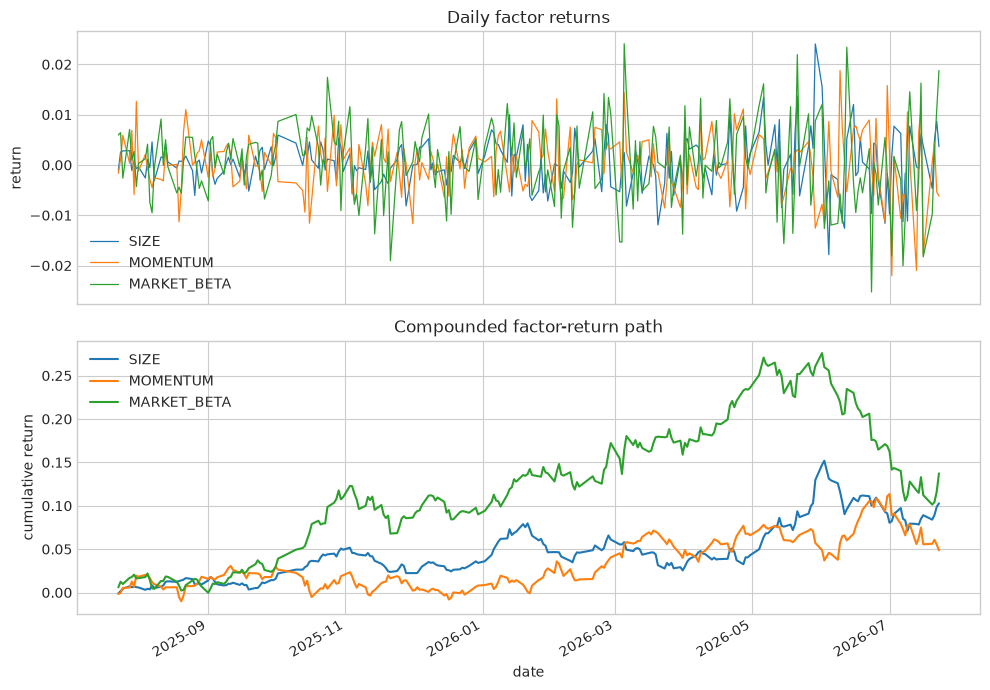

In [8]:
factor_columns = [name for name in result.model_columns if name != "INTERCEPT"]
factor_returns = result.factor_returns.set_index("date")[factor_columns]
cumulative = (1 + factor_returns).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
factor_returns.plot(ax=axes[0], linewidth=0.9, title="Daily factor returns")
cumulative.plot(ax=axes[1], linewidth=1.5, title="Compounded factor-return path")
axes[0].set_ylabel("return")
axes[1].set_ylabel("cumulative return")
axes[1].set_xlabel("date")
fig.tight_layout()
plt.show()

In [9]:
result.diagnostics[["n_observations", "rank", "r_squared", "residual_mean"]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_observations,244.0,1.980861e+02,6.258907e-01,1.970000e+02,1.980000e+02,1.980000e+02,1.980000e+02,1.990000e+02
rank,244.0,4.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
r_squared,244.0,9.846279e-02,8.601136e-02,4.457460e-04,4.077240e-02,7.786827e-02,1.305601e-01,5.120656e-01
residual_mean,244.0,1.173093e-18,1.292715e-17,-4.261462e-17,-3.592104e-18,2.803593e-19,5.081513e-18,6.567418e-17


## 5. Exercise the stages directly

The explicit form is useful for inspecting prepared exposures and an individual daily regression.

In [10]:
universe = universe_builder.build(source, window)
tickers = universe.index.get_level_values("ticker").unique()
history_start = window.start - pd.offsets.BDay(
    factor_model.history_business_days
)
market_data = source.load(history_start, window.end, tickers)
returns = return_calculator.calculate(market_data)
prepared_factors = factor_model.prepare(market_data, returns, universe)
first_date = result.factor_returns["date"].min()
first_membership = universe.xs(first_date)
first_tickers = first_membership.index[first_membership.to_numpy()]
first_exposures = prepared_factors.exposures(first_date, first_tickers)
first_fit = residualizer.fit(
    returns.xs(first_date).reindex(first_tickers), first_exposures
)
if first_fit is None:
    raise RuntimeError("first daily regression could not be fit")

pd.Series(
    {
        "loaded market rows": len(market_data),
        "dated membership rows": len(universe),
        "first-date exposure rows": len(first_exposures),
        "first-date regression R²": first_fit.r_squared,
    },
    name="value",
).to_frame()

,value
loaded market rows,98536.000000
dated membership rows,48800.000000
first-date exposure rows,200.000000
first-date regression R²,0.035981


## 6. Replace the factor model

A factor builder receives aligned date-by-ticker return and market-cap matrices. This example replaces momentum with short-term reversal while retaining recursive market beta.

In [11]:
def reversal(returns: pd.DataFrame, _: pd.DataFrame) -> pd.DataFrame:
    return -returns.shift(5)

custom_base_factor_model = resid.CharacteristicFactorModel(
    (
        resid.size_factor(name="SIZE"),
        resid.Factor(
            "REVERSAL", reversal, history_business_days=5
        ),
    )
)
custom_model = resid.RecursiveMarketBetaModel(
    base=custom_base_factor_model,
    lookback_days=market_beta_lookback_days,
    min_periods=market_beta_min_periods,
    decay=market_beta_decay,
)
custom_result = resid.run_pipeline(
    window=window,
    source=source,
    universe_builder=universe_builder,
    return_calculator=return_calculator,
    factor_model=custom_model,
    residualizer=residualizer,
)
custom_manifest = writer.write(custom_result, output_dir / "custom")
custom_result.factor_returns.head()

,date,INTERCEPT,SIZE,REVERSAL,MARKET_BETA
0,2025-07-23,0.005022,-0.001349,0.000750,0.005433
1,2025-07-24,-0.002070,0.002672,-0.002467,0.006542
2,2025-07-25,0.001249,0.003599,0.000192,-0.002776
3,2025-07-28,-0.009143,0.001924,-0.006183,0.006615
4,2025-07-29,0.005593,-0.000378,0.002109,-0.000170
